# Hall of Fame Probability — Starting Pitchers
**Logistic Regression Model | Baseball Reference Data**

## Overview

This model estimates the probability that a starting pitcher is inducted into the National Baseball Hall of Fame using logistic regression trained on the post-integration, post-WWII era (1945 onward).

**Qualification threshold:** 250+ career games started, debut before 2020, debut after 1945

**Features used:**
- `war7` — Peak 7-year WAR. Captures a pitcher's best sustained stretch without penalizing modern pitchers for lower inning totals
- `sowe` — A custom metric combining strikeouts, wins, and an ERA+ quality bonus

**Why not JAWS?** JAWS incorporates career WAR, which scales directly with innings pitched. A modern starter throwing 180 innings per season accumulates career WAR at a structurally lower rate than a 1990s starter throwing 250 innings — not because they are worse, but because organizational pitch count management has changed. Using JAWS as a feature would systematically underrate contemporary pitchers for decisions outside their control. `war7` evaluates peak dominance on a level playing field regardless of era.

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

df = pd.read_csv('startingpitchers.csv')
df = df[df['gs'] > 250]
df = df[df['fromyear'] < 2020]
df = df[df['toyear'] > 1945]

# Replace s_jaws with war7 + eraplus
# war7 = peak 7-year WAR (not innings dependent like career WAR)
# eraplus = park and era adjusted ERA, 100 is league average
df['sowe'] = df['so'] + df['w'] + ((df['eraplus'] - 100) * 15).clip(lower=0)
X = df[['war7','sowe']]
y = df['hof']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

model = LogisticRegression(class_weight={0:1, 1:2})
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))
for feat, coef in zip(X.columns, model.coef_[0]):
    print(f"{feat}: {coef:.5f}")

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        48
           1       0.57      0.67      0.62         6

    accuracy                           0.91        54
   macro avg       0.76      0.80      0.78        54
weighted avg       0.91      0.91      0.91        54

war7: 0.16333
sowe: 0.00109


## Feature Engineering

`sowe` (Strikeout-Win-ERA Excellence) is a custom career metric defined as:

```
sowe = SO + W + max(0, (ERA+ - 100) × 15)
```

Each component captures a different dimension of starting pitcher value:

- **SO** — Career strikeouts reward both durability and pure stuff. Unlike ERA, strikeouts are not park or defense dependent
- **W** — Career wins signal longevity and team contribution. Acknowledged limitation: wins are heavily team dependent and are the weakest component of this metric
- **ERA+ bonus** — For every point of ERA+ above 100 (league average), the pitcher receives 15 bonus points. The `max(0, ...)` clip ensures below-average seasons contribute 0 rather than subtracting from the total. This rewards sustained excellence in a park and era adjusted way

The 15× multiplier on the ERA+ bonus was chosen to put the quality component on a roughly comparable scale to the counting stats, preventing either from completely dominating the metric.

In [2]:
from sklearn.model_selection import cross_val_score

auc_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print(f"Cross-validated AUC: {auc_scores.mean():.3f} (+/- {auc_scores.std():.3f}")

Cross-validated AUC: 0.993 (+/- 0.015


## Model

Logistic regression with class weights {0: 1, 1: 2} — giving inducted pitchers twice the weight of non-inducted pitchers during training. This addresses class imbalance by ensuring the model does not default to predicting non-induction for borderline cases.

A precision-recall curve is used to identify the optimal classification threshold rather than defaulting to 0.5. Cross-validated AUC is reported as the primary performance metric.

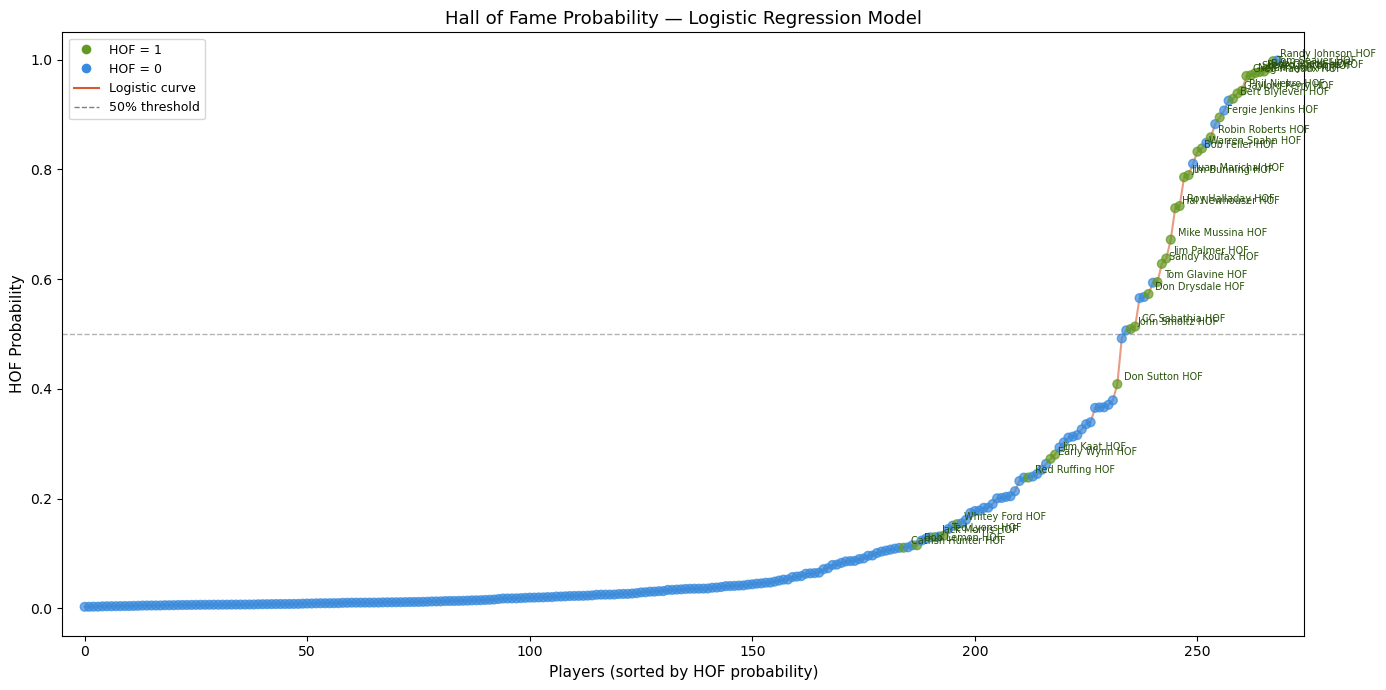

Saved.
                Player HOF Probability Inducted  FromYear
1        Roger Clemens           99.9%       No      1984
2    Randy Johnson HOF           99.7%      Yes      1988
3       Tom Seaver HOF           98.4%      Yes      1967
4       Bob Gibson HOF           97.9%      Yes      1959
5   Pedro Martínez HOF           97.8%      Yes      1992
6    Steve Carlton HOF           97.6%      Yes      1965
7       Nolan Ryan HOF           97.2%      Yes      1966
8      Greg Maddux HOF           97.1%      Yes      1986
9      Phil Niekro HOF           94.4%      Yes      1964
10   Gaylord Perry HOF           93.9%      Yes      1962
11   Bert Blyleven HOF           92.9%      Yes      1970
12    Justin Verlander           92.5%       No      2005
13     Clayton Kershaw           90.8%       No      2008
14  Fergie Jenkins HOF           89.5%      Yes      1965
15        Max Scherzer           88.3%       No      2008
16   Robin Roberts HOF           85.9%      Yes      1948
17     

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get predicted HOF probability for every player in df
df['hof_prob'] = model.predict_proba(X)[:, 1]

# Sort by probability for a cleaner plot
df_sorted = df.sort_values('hof_prob').reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

# Color dots by actual HOF status
colors = df_sorted['hof'].map({0: '#378ADD', 1: '#639922'})
ax.scatter(range(len(df_sorted)), df_sorted['hof_prob'], 
           c=colors, alpha=0.7, zorder=3, s=40)

# Logistic curve overlay — sorted probabilities IS the logistic line
ax.plot(range(len(df_sorted)), df_sorted['hof_prob'], 
        color='#D85A30', linewidth=1.5, alpha=0.6, zorder=2)

# 50% threshold line
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)

# Label every actual HOFer by name
for idx, row in df_sorted.iterrows():
    if row['hof'] == 1:
        ax.annotate(row['name'], 
                    xy=(idx, row['hof_prob']),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=7, color='#27500A')

# Formatting
ax.set_xlabel('Players (sorted by HOF probability)', fontsize=11)
ax.set_ylabel('HOF Probability', fontsize=11)
ax.set_title('Hall of Fame Probability — Logistic Regression Model', fontsize=13)
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(-5, len(df_sorted) + 5)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#639922', markersize=8, label='HOF = 1'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#378ADD', markersize=8, label='HOF = 0'),
    Line2D([0], [0], color='#D85A30', linewidth=1.5, label='Logistic curve'),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=1, label='50% threshold')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('sp_probability_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

df_table = df[['name', 'hof_prob', 'hof','fromyear']].copy()

# Sort numerically FIRST while it's still a float
df_table = df_table.sort_values('hof_prob', ascending=False).reset_index(drop=True)
df_table.index += 1
df_table['fromyear'] = (df_table['fromyear']).astype(int)
df_table = df_table[df_table['fromyear'] >= 1945]
# THEN convert to string with % sign
df_table['hof_prob'] = (df_table['hof_prob'] * 100).round(1).astype(str) + '%'
df_table['hof'] = df_table['hof'].map({1: 'Yes', 0: 'No'})
df_table.columns = ['Player', 'HOF Probability', 'Inducted','FromYear']

df_table.to_csv('sp_probabilities.csv')
print(df_table.head(20))

In [4]:
print(f"Intercept: {model.intercept_[0]:.10f}")
print(f"WAR7 coef: {model.coef_[0][0]:.10f}")
print(f"SOWE coef: {model.coef_[0][1]:.10f}")

Intercept: -10.2933856028
WAR7 coef: 0.1633288261
SOWE coef: 0.0010917611


## Results and Interpretation

The war7 and sowe coefficients reveal how the model weighted peak dominance versus career contribution. A high war7 coefficient suggests HOF voters reward pitchers who had elite multi-year stretches even if their career totals were not overwhelming.

Active or recently retired pitchers who score highly represent the strongest current HOF cases by these metrics. Note that pitchers who debuted after approximately 2005 are likely underrepresented in the HOF-inducted training class, so predictions for very recent pitchers should be interpreted with that caveat in mind.

Best threshold for max precision: 0.730
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        48
           1       0.60      0.50      0.55         6

    accuracy                           0.91        54
   macro avg       0.77      0.73      0.75        54
weighted avg       0.90      0.91      0.90        54



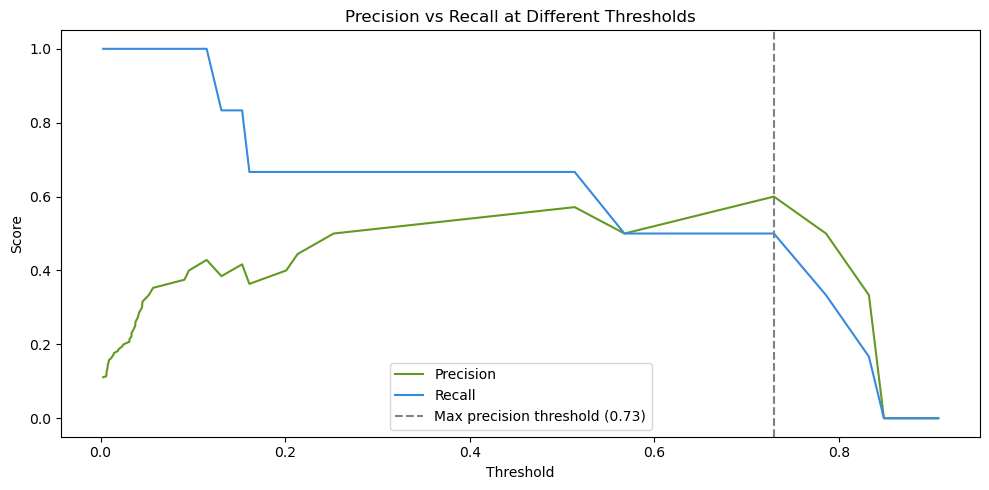

In [5]:
from sklearn.metrics import precision_recall_curve

y_prob = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Find threshold that gives maximum precision while still catching at least 1 HOFer
best_threshold = thresholds[precision[:-1].argmax()]
print(f"Best threshold for max precision: {best_threshold:.3f}")

# See what the classification report looks like at that threshold
y_pred_strict = (y_prob >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_strict))
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision[:-1], label='Precision', color='#639922')
plt.plot(thresholds, recall[:-1], label='Recall', color='#378ADD')
plt.axvline(best_threshold, color='gray', linestyle='--', label=f'Max precision threshold ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.tight_layout()
plt.show()